In [1]:
library(Giotto)
library(data.table)
library(data.table)
library(Matrix)


In [8]:
library(data.table)

path_to_matrix <- paste0(
  "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/",
  "Benchmark/SimMerfish/decov/sc_expression.tsv"
)

path_to_locations <- paste0(
  "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/",
  "Benchmark/SimMerfish/decov/spatial_coords.tsv"
)

expr_raw <- fread(
  path_to_matrix,
  sep = "\t",
  header = TRUE,
  data.table = FALSE,
  check.names = FALSE
)

loc_raw <- fread(
  path_to_locations,
  sep = "\t",
  header = TRUE,
  data.table = FALSE,
  check.names = FALSE
)

cat("Expression file dimensions:", dim(expr_raw), "\n")
cat("Location file dimensions:", dim(loc_raw), "\n")

cat("\nExpression first columns:\n")
print(colnames(expr_raw)[1:min(6, ncol(expr_raw))])

cat("\nLocation columns:\n")
print(colnames(loc_raw))

cat("\nExpression preview:\n")
print(expr_raw[1:min(3, nrow(expr_raw)),
               1:min(6, ncol(expr_raw)),
               drop = FALSE])

cat("\nLocation preview:\n")
print(head(loc_raw))

Expression file dimensions: 254 4199 
Location file dimensions: 424 3 

Expression first columns:
[1] "Gene"                                   
[2] "100047181052654346224529175853339022386"
[3] "100144987682981782100923292757524648699"
[4] "100267747580756240041023704492842942950"
[5] "100380418078413692631351412383892166094"
[6] "100416591302420540942373170232872783233"

Location columns:
[1] "SpotID" "row"    "col"   

Expression preview:
           Gene 100047181052654346224529175853339022386
1 1700022I11Rik                                       0
2 1810046K07Rik                                       0
3 5031425F14Rik                                       0
  100144987682981782100923292757524648699
1                                       0
2                                       0
3                                       0
  100267747580756240041023704492842942950
1                                       0
2                                       0
3                                    

In [9]:
library(Giotto)

# 1. Directly from the file paths
path_to_matrix = "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/st_expression.tsv"
path_to_locations =  "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/spatial_coords.tsv"
my_python_path <- "/home/qyyuan/anaconda3/envs/SpatialDWLS/bin/python"
my_instructions <- createGiottoInstructions(
    python_path = my_python_path
)
my_giotto_object = createGiottoObject(raw_exprs = path_to_matrix,
                  spatial_locs = path_to_locations,instructions = my_instructions)





 external python path provided and will be used 
Consider to install these (optional) packages to run all possible Giotto commands for spatial analyses:  scran MAST smfishHmrf trendsceek SPARK multinet RTriangle FactoMiner
 Giotto does not automatically install all these packages as they are not absolutely required and this reduces the number of dependencies

In [10]:
my_giotto_object <- filterGiotto(gobject = my_giotto_object,
             expression_threshold = 1,
             gene_det_in_min_cells = 10,
             min_det_genes_per_cell = 5)

In [11]:
my_giotto_object <- normalizeGiotto(gobject = my_giotto_object, scalefactor = 6000, verbose = T)



 first scale genes and then cells 


return_plot = TRUE and return_gobject = TRUE 

          plot will not be returned to object, but can still be saved with save_plot = TRUE or manually 


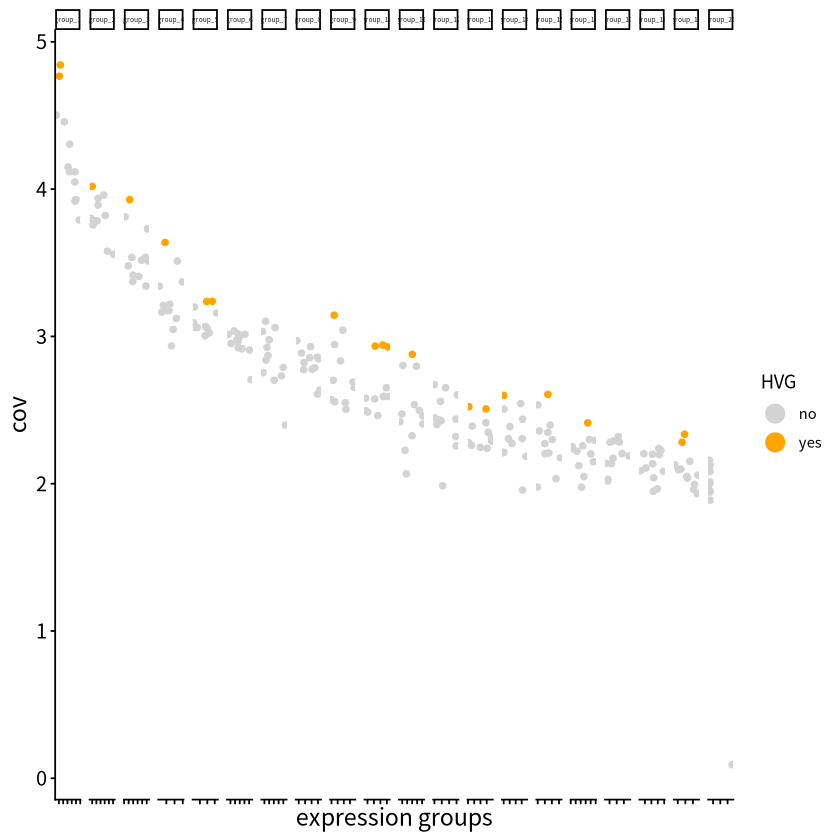

In [12]:
my_giotto_object <- calculateHVG(gobject = my_giotto_object)

hvg  was found in the gene metadata information and will be used to select highly variable genes 


Warning message in runPCA_prcomp_irlba(x = t_giotto(expr_values), center = center, :
“ncp >= minimum dimension of x, will be set to minimum dimension of x - 1”
Warning message in (function (A, nv = 5, nu = nv, maxit = 1000, work = nv + 7, reorth = TRUE, :
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message in (function (A, nv = 5, nu = nv, maxit = 1000, work = nv + 7, reorth = TRUE, :
“did not converge--results might be invalid!; try increasing work or maxit”


PCA with name:  pca  already exists and will be used for the screeplot 


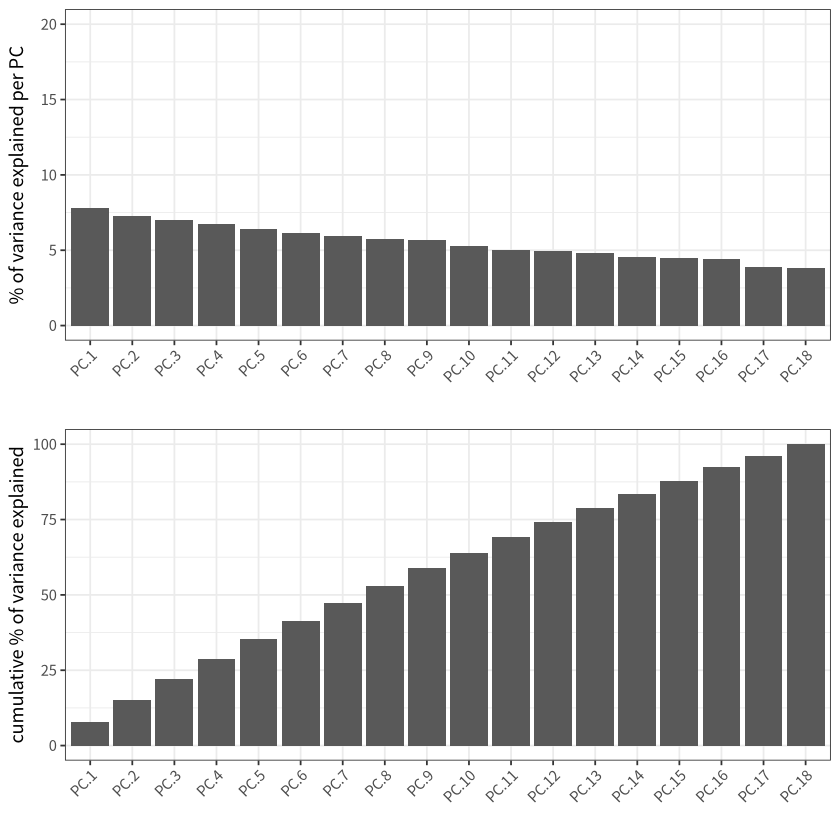

using 'jackstraw' to identify significant PCs If used in published research, please cite:
  Neo Christopher Chung and John D. Storey (2014).
  'Statistical significance of variables driving systematic variation in high-dimensional data. Bioinformatics

Estimating a number of significant principal component: 



1  2  3  4  5  6  7  8  9  10  number of estimated significant components:  NA 


Warning message:
“Removed 20 rows containing missing values or values outside the scale range
(`geom_point()`).”


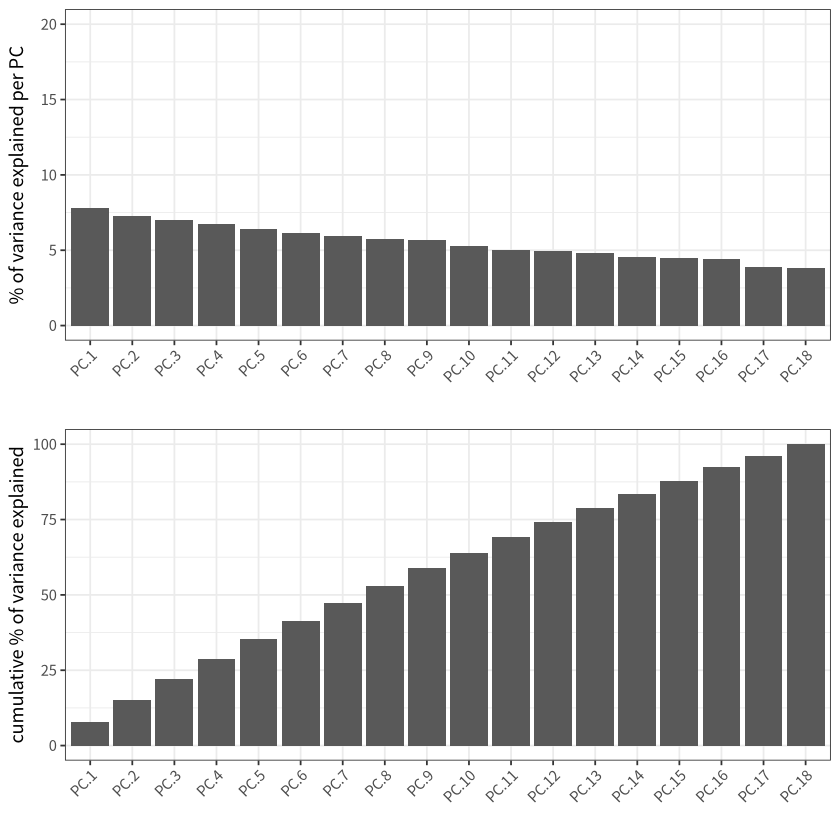

Warning message:
“Removed 20 rows containing missing values or values outside the scale range
(`geom_point()`).”


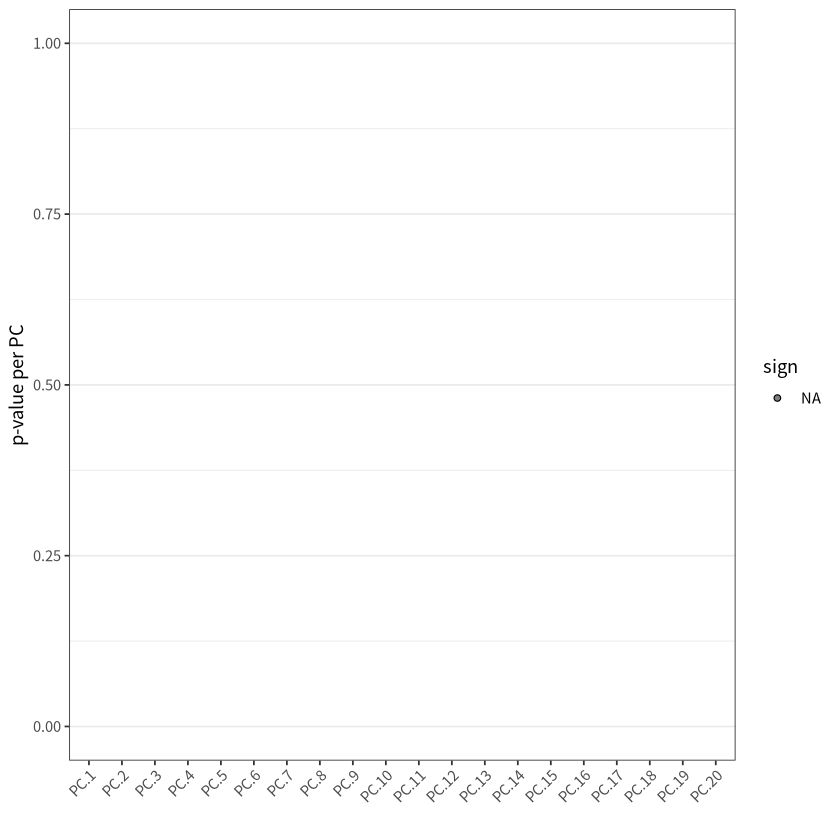

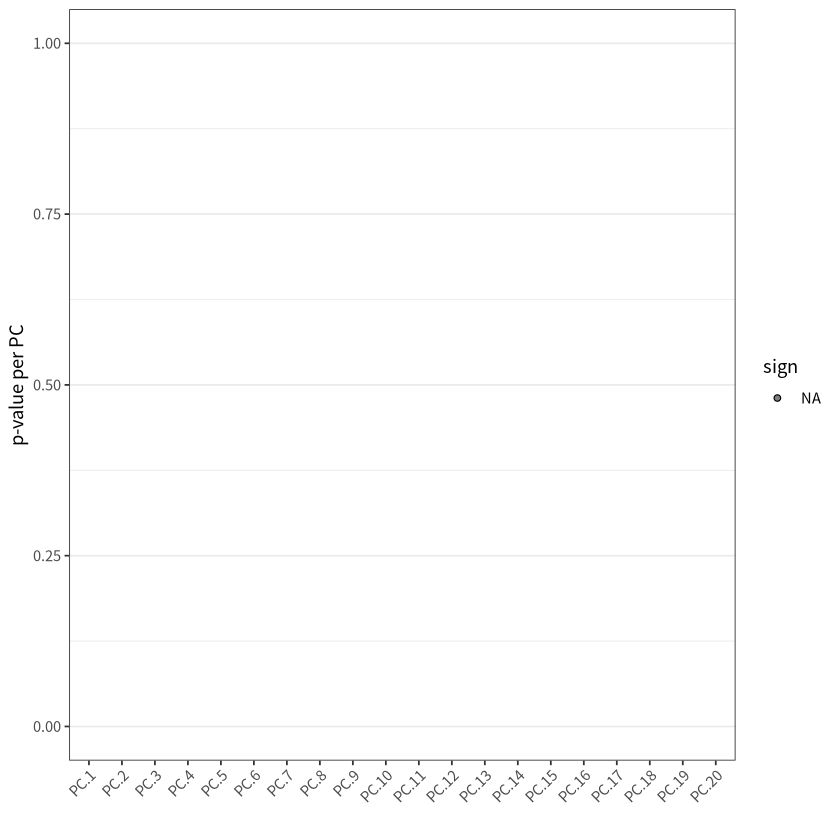

In [13]:
# Run PCA
my_giotto_object <- runPCA(gobject = my_giotto_object)

# Identify most informative principal components
screePlot(my_giotto_object, ncp = 20)
jackstrawPlot(my_giotto_object, ncp = 20)

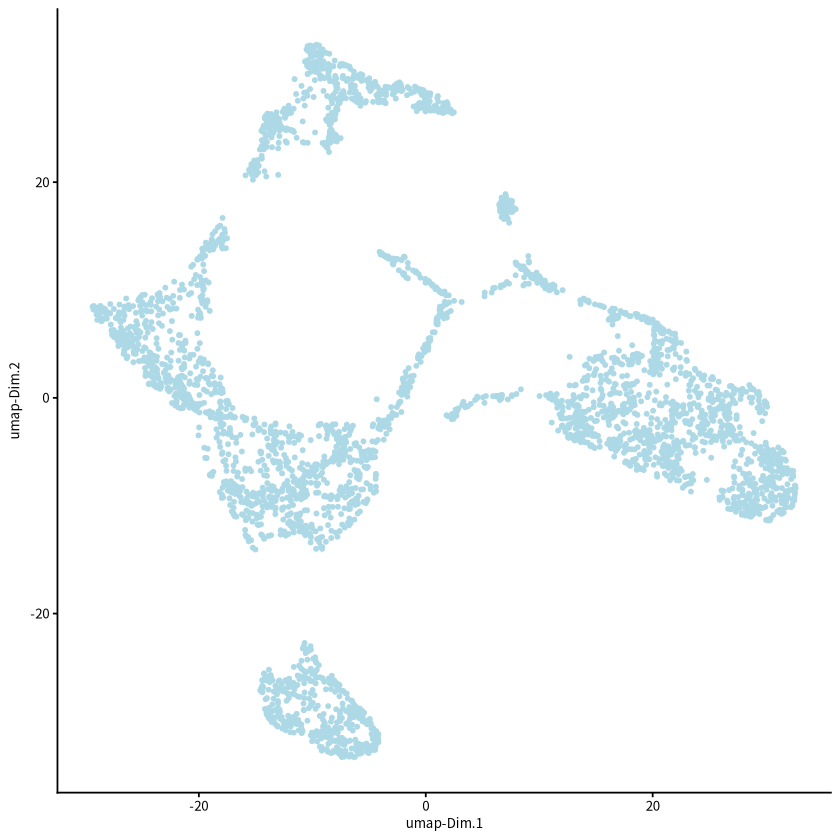

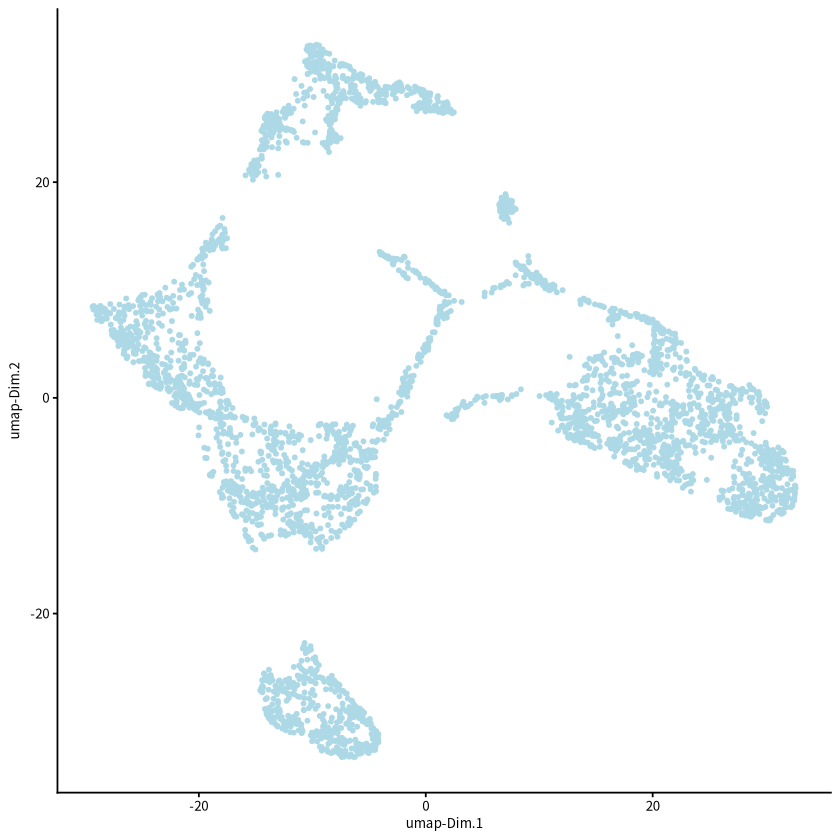

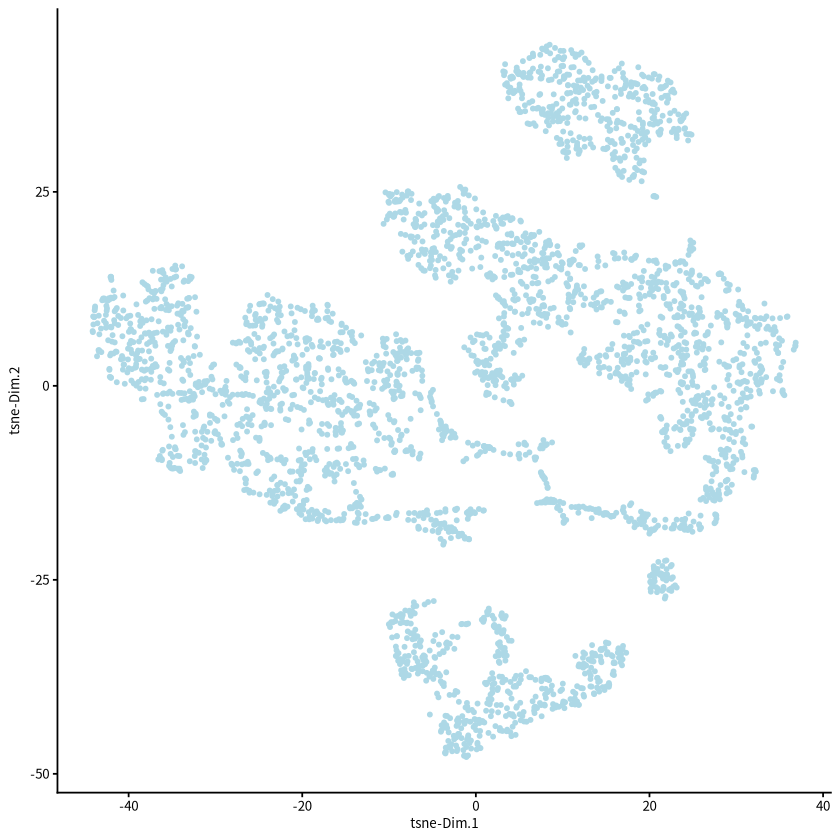

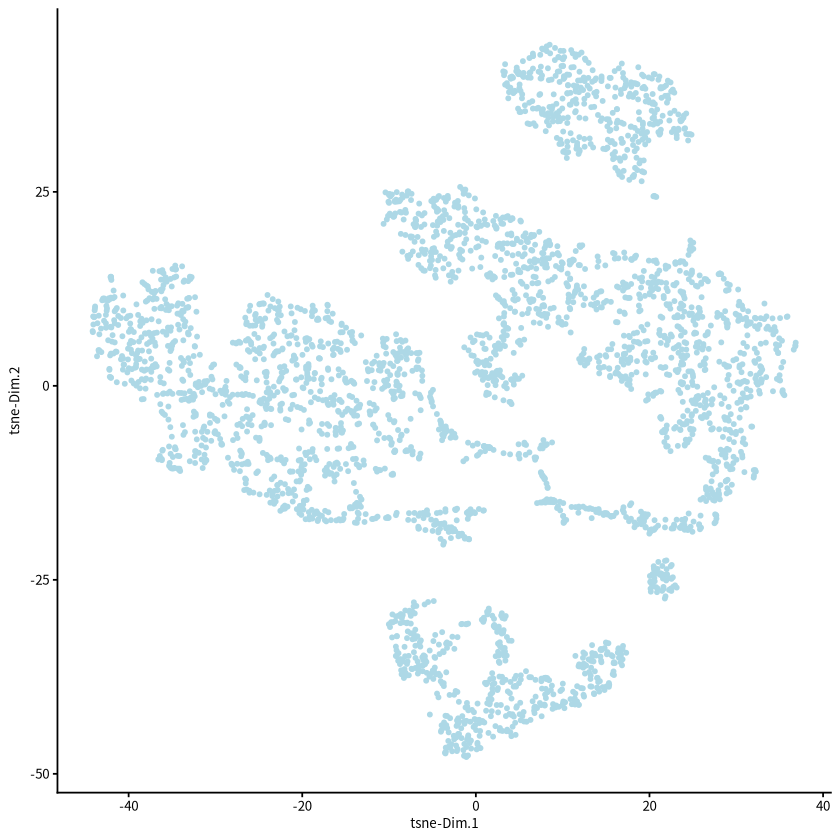

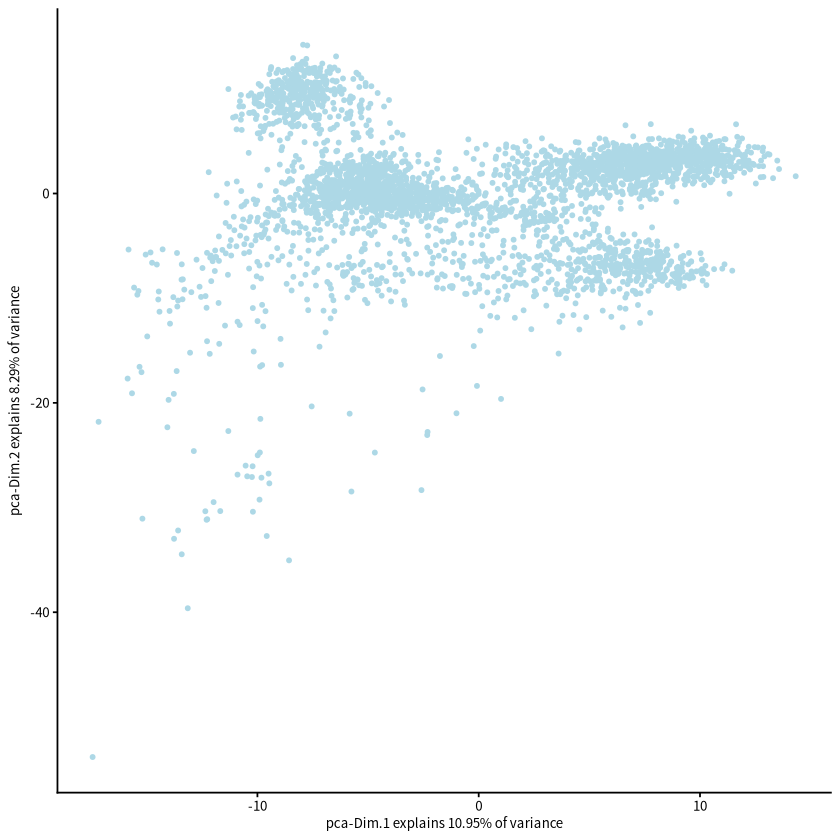

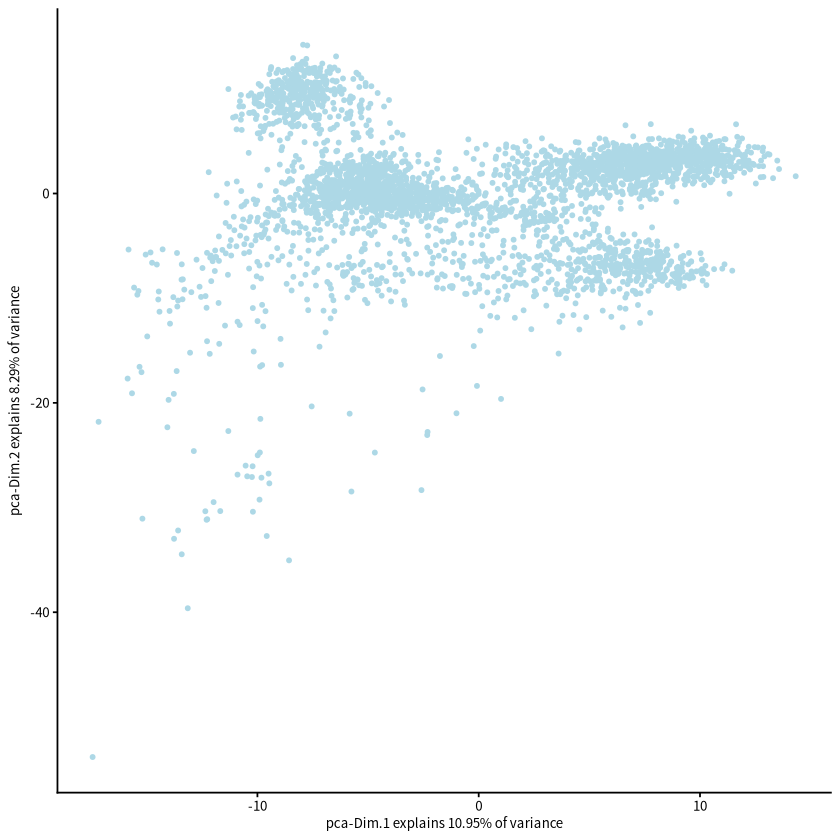

In [21]:
# UMAP
my_giotto_object <- runUMAP(my_giotto_object, dimensions_to_use = 1:5)
plotUMAP(gobject = my_giotto_object)

# TSNE
my_giotto_object <- runtSNE(my_giotto_object, dimensions_to_use = 1:5)
plotTSNE(gobject = my_giotto_object)

# plot PCA results
plotPCA(my_giotto_object)

In [21]:
my_giotto_object = doHclust(my_giotto_object, k = 4, name = 'hier_clus')



  hier_clus  has already been used, will be overwritten 


In [24]:
my_giotto_object@cell_metadata$hier_clus=

ERROR: Error in parse(text = input): <text>:2:0: unexpected end of input
1: my_giotto_object@cell_metadata$hier_clus=
   ^


In [25]:
single_cell_DT = fread('/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/sc_expression.tsv')
single_cell_matrix = Giotto:::dt_to_matrix(single_cell_DT)
single_cell_matrix[1:4, 1:4]



4 x 4 sparse Matrix of class "dgCMatrix"
              100047181052654346224529175853339022386
1700022I11Rik                                       .
1810046K07Rik                                       .
5031425F14Rik                                       .
5730522E02Rik                                       .
              100144987682981782100923292757524648699
1700022I11Rik                                       .
1810046K07Rik                                       .
5031425F14Rik                                       .
5730522E02Rik                                       .
              100267747580756240041023704492842942950
1700022I11Rik                                       .
1810046K07Rik                                       .
5031425F14Rik                                       .
5730522E02Rik                                       .
              100380418078413692631351412383892166094
1700022I11Rik                                       .
1810046K07Rik                            

In [64]:
# Single cell annotation vector
cell_annotations = read.table(file = '/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/decov/cell_type_labels.tsv',  sep = "\t", header= TRUE)


In [65]:
print(cell_annotations)

         Cell.IDs   CellType
1    1.000472e+38      Oligo
2    1.001450e+38       VLMC
3    1.002677e+38      Astro
4    1.003804e+38    L4_5_IT
5    1.004166e+38    L4_5_IT
6    1.004376e+38      L5_IT
7    1.005200e+38       VLMC
8    1.005427e+38    L4_5_IT
9    1.007101e+38    L2_3_IT
10   1.007117e+38    L4_5_IT
11   1.007705e+38    L2_3_IT
12   1.008425e+38      L5_IT
13   1.009510e+38    L2_3_IT
14   1.009556e+38      Astro
15   1.010403e+38       Endo
16   1.012903e+38      Oligo
17   1.013365e+37      L6_IT
18   1.014011e+36    L4_5_IT
19   1.015144e+38        Sst
20   1.017314e+38      L5_ET
21   1.018320e+38      L6_CT
22   1.018507e+38      L5_IT
23   1.019234e+38    L4_5_IT
24   1.019477e+38    L2_3_IT
25   1.021112e+37       Peri
26   1.021384e+38      Oligo
27   1.022959e+38      L5_IT
28   1.023299e+38      L5_ET
29   1.023691e+38        PVM
30   1.025005e+38      L6_IT
31   1.026051e+38       VLMC
32   1.026308e+38       VLMC
33   1.027192e+38       Endo
34   1.027628e

In [66]:
cell_annotations = as.vector(cell_annotations$CellType)
cell_annotations[1:10]

# 1.2 create rank matrix
rank_matrix = makeSignMatrixRank(sc_matrix = single_cell_matrix, sc_cluster_ids = cell_annotations)


# 1.3 enrichment test with RANK
# runSpatialEnrich() can also be used as a wrapper for all currently provided enrichment options
my_giotto_object = runRankEnrich(gobject = my_giotto_object, sign_matrix = rank_matrix)



[1] "Oligo"   "VLMC"    "Astro"   "L4_5_IT" "L4_5_IT" "L5_IT"   "VLMC"   
 [8] "L4_5_IT" "L2_3_IT" "L4_5_IT"

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Giotto package.
  Please report the issue at <https://github.com/RubD/Giotto/issues>.”


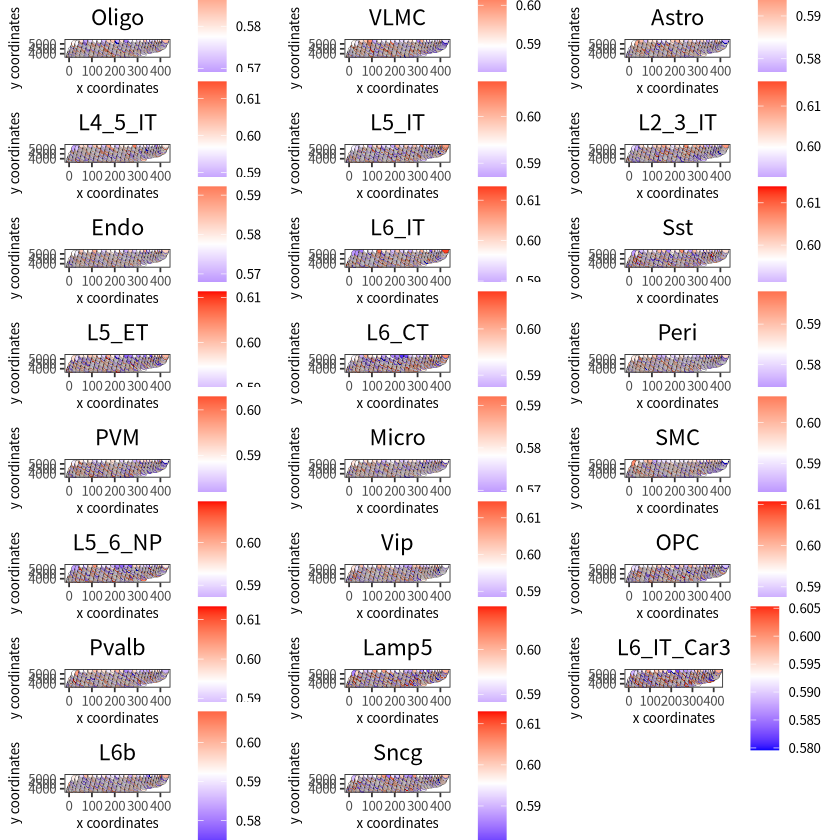

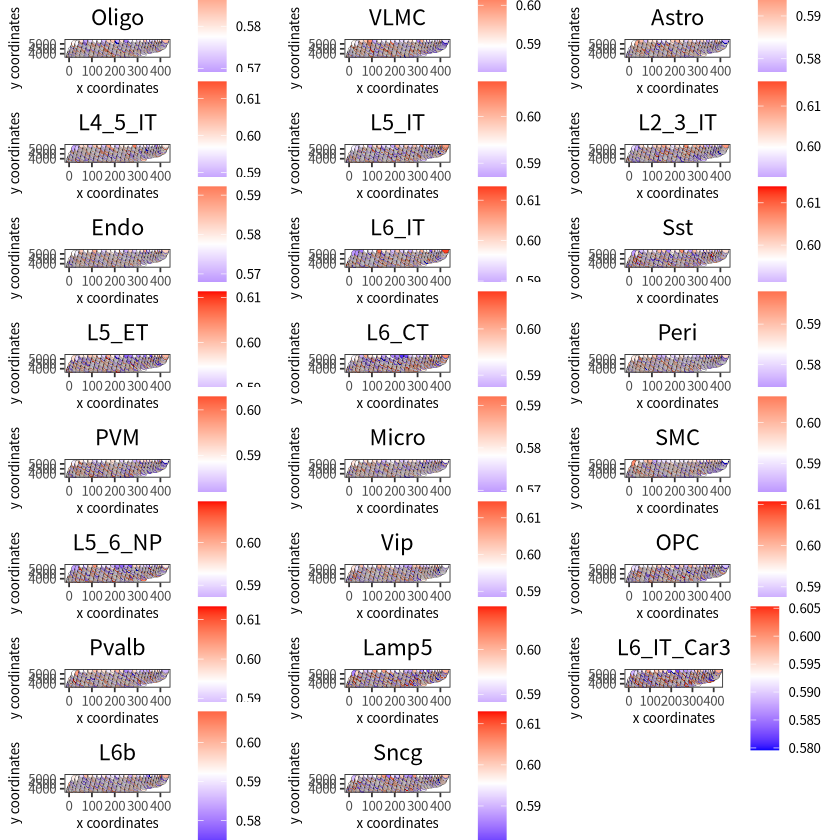

In [67]:
cell_types_subset = unique(cell_annotations)
spatCellPlot(gobject = my_giotto_object,
     spat_enr_names = 'rank',
     cell_annotation_values = cell_types_subset,
     cow_n_col = 3,coord_fix_ratio = NULL, point_size = 1.75)

In [38]:
markersall=read.table('/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/makers.txt',sep='\t',header=T)

In [68]:
markersall=read.table('/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/makers_zztry.txt',sep='\t',header=T)

In [ ]:
/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/SimMerfish/makers_zztry.txt

In [69]:
# 筛选条件
selected <- markersall[markersall$p_val_adj < 0.00001 & markersall$avg_log2FC > 4, ]

# 按 cluster 分组，提取基因名称
marker_genes_per_cluster <- split(selected$gene, selected$cluster)

In [70]:
# 假设 marker_genes_per_cluster 是之前生成的命名列表
# 只保留基因长度大于 0 的 cluster
sign_list <- marker_genes_per_cluster[lengths(marker_genes_per_cluster) > 0]
sign_names <- names(sign_list)

# 生成签名矩阵（需加载 Giotto 或相关包）
signature_matrix <- makeSignMatrixPAGE(
    sign_names = sign_names,
    sign_list = sign_list
)

# 查看结果
dim(signature_matrix)
colnames(signature_matrix)  # 显示签名名称

[1] 49 19

[1] "Astro"      "Endo"       "L2_3_IT"    "L5_6_NP"    "L6_CT"     
 [6] "L6_IT_Car3" "L6b"        "Lamp5"      "Micro"      "OPC"       
[11] "Oligo"      "PVM"        "Peri"       "Pvalb"      "SMC"       
[16] "Sncg"       "Sst"        "VLMC"       "Vip"

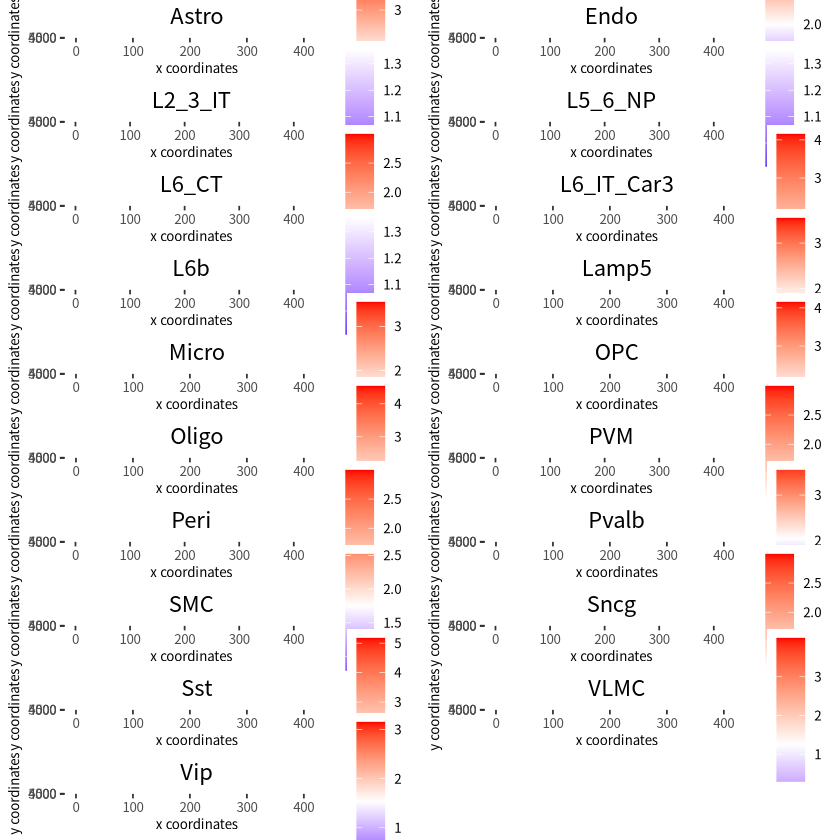

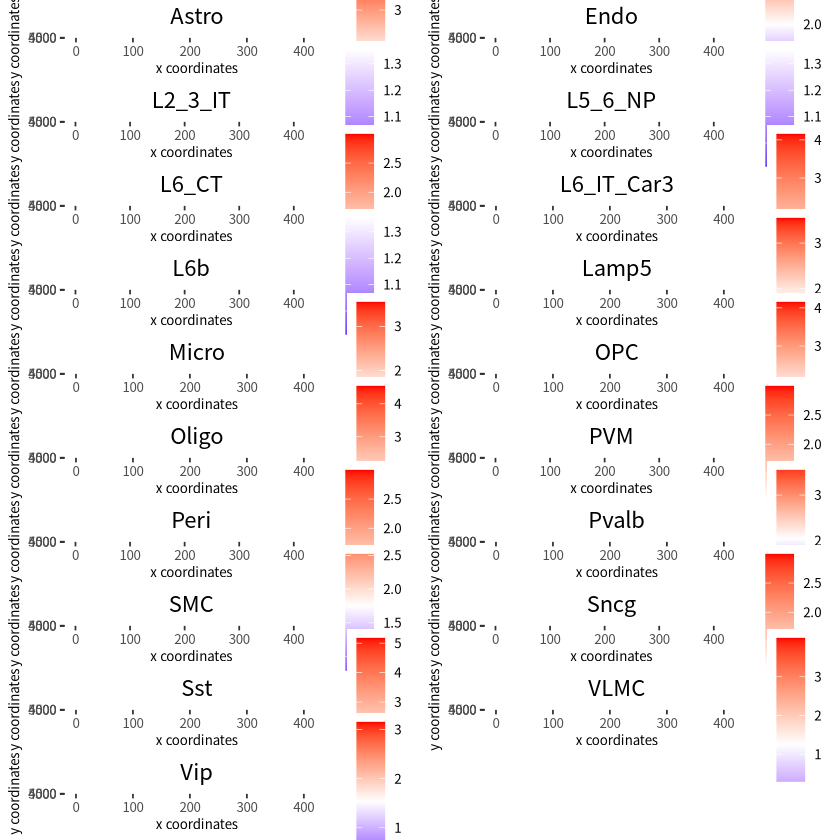

In [71]:
my_giotto_object = runHyperGeometricEnrich(gobject = my_giotto_object,
                   sign_matrix = signature_matrix)

cell_types_subset = colnames(signature_matrix)
spatCellPlot(gobject = my_giotto_object,
     spat_enr_names = 'hypergeometric',
     cell_annotation_values = cell_types_subset,
     cow_n_col = 2,coord_fix_ratio = NULL, point_size = 2.75)

In [72]:
saveRDS(my_giotto_object, file = "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/spatialDWLS_result/my_giotto_object_merfish_zztry.rds")
saveRDS(signature_matrix, file = "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/spatialDWLS_result/signature_matrix_merfish_zztry.rds")

In [73]:
my_giotto_object=readRDS("/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/spatialDWLS_result/my_giotto_object_merfish_zztry.rds")
signature_matrix=readRDS("/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/spatialDWLS_result/signature_matrix_merfish_zztry.rds")

In [85]:
cat("signature_matrix class:", class(signature_matrix), "\n")
cat(
  "signature_matrix dimensions:",
  paste(dim(signature_matrix), collapse = " × "),
  "\n"
)

cat("Has rownames:", !is.null(rownames(signature_matrix)), "\n")
cat("Has colnames:", !is.null(colnames(signature_matrix)), "\n")

cat("First signature genes:\n")
print(head(rownames(signature_matrix)))

cat("Cell types:\n")
print(colnames(signature_matrix))

signature_matrix class: matrix array 
signature_matrix dimensions: 49 × 19 
Has rownames: TRUE 
Has colnames: TRUE 
First signature genes:
[1] "Adamts4" "Asic4"   "Bgn"     "Cd14"    "Chat"    "Cldn5"  
Cell types:
 [1] "Astro"      "Endo"       "L2_3_IT"    "L5_6_NP"    "L6_CT"     
 [6] "L6_IT_Car3" "L6b"        "Lamp5"      "Micro"      "OPC"       
[11] "Oligo"      "PVM"        "Peri"       "Pvalb"      "SMC"       
[16] "Sncg"       "Sst"        "VLMC"       "Vip"       


In [86]:
# 获取 Giotto 空间表达矩阵
st_expr <- getExpression(
  my_giotto_object,
  values = "normalized",
  output = "matrix"
)

cat("ST expression dimensions:",
    paste(dim(st_expr), collapse = " × "), "\n")

cat("ST genes:", nrow(st_expr), "\n")
cat("Signature genes:", nrow(signature_matrix), "\n")

common_genes <- intersect(
  rownames(st_expr),
  rownames(signature_matrix)
)

cat("Common genes:", length(common_genes), "\n")

cat("\nST-only examples:\n")
print(head(setdiff(rownames(st_expr), rownames(signature_matrix)), 20))

cat("\nSignature-only examples:\n")
print(head(setdiff(rownames(signature_matrix), rownames(st_expr)), 20))

ERROR: Error in getExpression(my_giotto_object, values = "normalized", output = "matrix"): 没有"getExpression"这个函数


In [87]:
head(rownames(st_expr))
head(rownames(signature_matrix))

ERROR: Error in h(simpleError(msg, call)): 在为函数“head”选择方法时计算参数“x”时出错：找不到对象'st_expr'


In [74]:
my_giotto_object@cell_metadata$cluster=my_giotto_object@cell_metadata$hier_clus

In [93]:
cat("Giotto object class:\n")
print(class(my_giotto_object))

cat("\nGiotto object slots:\n")
print(slotNames(my_giotto_object))

Giotto object class:
[1] "giotto"
attr(,"package")
[1] "Giotto"

Giotto object slots:
 [1] "raw_exprs"           "norm_expr"           "norm_scaled_expr"   
 [4] "custom_expr"         "spatial_locs"        "cell_metadata"      
 [7] "gene_metadata"       "cell_ID"             "gene_ID"            
[10] "spatial_network"     "spatial_grid"        "spatial_enrichment" 
[13] "dimension_reduction" "nn_network"          "images"             
[16] "parameters"          "instructions"        "offset_file"        
[19] "OS_platform"        


In [94]:
extract_giotto_expression <- function(
    gobject,
    prefer_normalized = TRUE
) {
  object_slots <- slotNames(gobject)

  cat(
    "Available Giotto slots:",
    paste(object_slots, collapse = ", "),
    "\n"
  )

  candidate_slots <- if (prefer_normalized) {
    c(
      "norm_expr",
      "normalized_expr",
      "raw_exprs",
      "expression"
    )
  } else {
    c(
      "raw_exprs",
      "expression",
      "norm_expr",
      "normalized_expr"
    )
  }

  for (slot_name in candidate_slots) {
    if (slot_name %in% object_slots) {
      value <- slot(gobject, slot_name)

      if (!is.null(value)) {
        value_dim <- tryCatch(
          dim(value),
          error = function(e) NULL
        )

        if (!is.null(value_dim) && length(value_dim) == 2) {
          message(
            "Using Giotto slot: ",
            slot_name,
            "; dimensions: ",
            paste(value_dim, collapse = " × ")
          )

          return(value)
        }

        # 有些Giotto版本将表达矩阵储存在list中
        if (is.list(value) && length(value) > 0) {
          cat(
            "Slot '", slot_name,
            "' is a list with names: ",
            paste(names(value), collapse = ", "),
            "\n",
            sep = ""
          )

          # 优先寻找 raw 或 normalized
          preferred_names <- c(
            "normalized",
            "raw",
            "rna",
            "RNA"
          )

          for (element_name in preferred_names) {
            if (
              !is.null(names(value)) &&
              element_name %in% names(value)
            ) {
              candidate <- value[[element_name]]
              candidate_dim <- tryCatch(
                dim(candidate),
                error = function(e) NULL
              )

              if (
                !is.null(candidate_dim) &&
                length(candidate_dim) == 2
              ) {
                message(
                  "Using list element: ",
                  slot_name,
                  "$",
                  element_name,
                  "; dimensions: ",
                  paste(candidate_dim, collapse = " × ")
                )

                return(candidate)
              }
            }
          }

          # 如果没有名称，逐个寻找二维矩阵
          for (i in seq_along(value)) {
            candidate <- value[[i]]
            candidate_dim <- tryCatch(
              dim(candidate),
              error = function(e) NULL
            )

            if (
              !is.null(candidate_dim) &&
              length(candidate_dim) == 2
            ) {
              message(
                "Using element ",
                i,
                " from slot ",
                slot_name,
                "; dimensions: ",
                paste(candidate_dim, collapse = " × ")
              )

              return(candidate)
            }
          }
        }
      }
    }
  }

  stop(
    "未能从Giotto对象中找到二维表达矩阵。\n",
    "请查看 slotNames(my_giotto_object) 和 ",
    "str(my_giotto_object, max.level = 2)。"
  )
}


st_expr <- extract_giotto_expression(
  my_giotto_object,
  prefer_normalized = TRUE
)

Available Giotto slots: raw_exprs, norm_expr, norm_scaled_expr, custom_expr, spatial_locs, cell_metadata, gene_metadata, cell_ID, gene_ID, spatial_network, spatial_grid, spatial_enrichment, dimension_reduction, nn_network, images, parameters, instructions, offset_file, OS_platform 


Using Giotto slot: norm_expr; dimensions: 236 × 421



In [95]:
cat(
  "Extracted expression dimensions:",
  paste(dim(st_expr), collapse = " × "),
  "\n"
)

cat("Has gene names:", !is.null(rownames(st_expr)), "\n")
cat("Has spot names:", !is.null(colnames(st_expr)), "\n")

print(head(rownames(st_expr)))
print(head(colnames(st_expr)))

Extracted expression dimensions: 236 × 421 
Has gene names: TRUE 
Has spot names: TRUE 
[1] "Gene"          "1810046K07Rik" "5730522E02Rik" "Acta2"        
[5] "Adam2"         "Adamts2"      
[1] "V3" "V4" "V5" "V6" "V7" "V8"


In [96]:
common_upper <- intersect(
  toupper(rownames(st_expr)),
  toupper(rownames(signature_matrix))
)

cat(
  "Common genes after converting to uppercase:",
  length(common_upper),
  "\n"
)

Common genes after converting to uppercase: 45 


In [97]:
common_genes <- intersect(
  rownames(st_expr),
  rownames(signature_matrix)
)

if (length(common_genes) < 2) {
  stop(
    "共同 signature genes 只有 ",
    length(common_genes),
    " 个，无法稳定运行 DWLS。"
  )
}

signature_matrix_dwls <- signature_matrix[
  common_genes,
  ,
  drop = FALSE
]

# 删除含有NA/Inf的基因
valid_genes <- apply(
  signature_matrix_dwls,
  1,
  function(x) {
    all(is.finite(x)) &&
      !anyNA(x)
  }
)

signature_matrix_dwls <- signature_matrix_dwls[
  valid_genes,
  ,
  drop = FALSE
]

# 删除全零或无变化的细胞类型
valid_celltypes <- apply(
  signature_matrix_dwls,
  2,
  function(x) {
    sum(x > 0, na.rm = TRUE) >= 2 &&
      sd(x, na.rm = TRUE) > 0
  }
)

signature_matrix_dwls <- signature_matrix_dwls[
  ,
  valid_celltypes,
  drop = FALSE
]

cat(
  "Final signature dimensions:",
  paste(dim(signature_matrix_dwls), collapse = " × "),
  "\n"
)

print(colnames(signature_matrix_dwls))

Final signature dimensions: 45 × 16 
 [1] "Astro"      "Endo"       "L6_CT"      "L6_IT_Car3" "Lamp5"     
 [6] "Micro"      "OPC"        "Oligo"      "PVM"        "Peri"      
[11] "Pvalb"      "SMC"        "Sncg"       "Sst"        "VLMC"      
[16] "Vip"       


In [99]:
my_giotto_object <- runDWLSDeconv(
  gobject = my_giotto_object,
  sign_matrix = signature_matrix_dwls,
  cluster_column = "hier_clus",
  expression_values = "normalized",
  cutoff = 0,
  n_cell = 50,
  name = "DWLS",
  return_gobject = TRUE
)

[1] "The 45 overlapped genes between signature matrix and\nspatial expression profile"


In [100]:
saveRDS(my_giotto_object, file = "/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/spatialDWLS_result/my_giotto_object_zztry.rds")


In [ ]:
my_giotto_object=readRDS("/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/spatialDWLS_result/my_giotto_object_zztry.rds")
write.table(my_giotto_object@cell_metadata, file='Spot_cluster_zztry.txt',sep='\t',quote = F)
write.table(my_giotto_object@spatial_enrichment$DWLS,file = 'spatialDWLS_dec_zztry.csv',sep=',',quote = F,row.names = F)